In [ ]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
    classification_report
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
TARGET_COL = 'Prediction'

In [ ]:
# Load Dataset
df = pd.read_csv('liver_cancer_prediction.csv')
df.head()

,Country,Region,Population,Incidence_Rate,Mortality_Rate,Gender,Age,Alcohol_Consumption,Smoking_Status,Hepatitis_B_Status,...,Herbal_Medicine_Use,Healthcare_Access,Screening_Availability,Treatment_Availability,Liver_Transplant_Access,Ethnicity,Preventive_Care,Survival_Rate,Cost_of_Treatment,Prediction
0,Nigeria,Sub-Saharan Africa,340672131,15.381360,6.160480,Male,81,Low,Smoker,Negative,...,No,Poor,Available,Available,No,Hispanic,Good,17.724793,47486.167423,Yes
1,United Kingdom,Europe,1054632817,3.306101,14.392985,Male,87,Low,Smoker,Negative,...,Yes,Good,Available,Not Available,No,Mixed,Moderate,19.558853,13782.265151,No
2,India,South Asia,751241440,9.325053,12.777878,Male,34,Moderate,Smoker,Negative,...,No,Good,Not Available,Not Available,No,Mixed,Moderate,68.468892,25308.034132,No
3,Colombia,South America,1167333367,9.399658,8.634609,Male,63,Low,Non-Smoker,Positive,...,No,Good,Not Available,Not Available,Yes,Hispanic,Moderate,18.200287,38221.622202,No
4,Iran,Middle East,1082070787,9.665663,12.422518,Male,85,High,Non-Smoker,Positive,...,Yes,Moderate,Available,Available,Yes,Mixed,Moderate,45.019153,26765.301404,No


In [ ]:
# Preprocessing

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (160292, 25)

Columns:
['Country', 'Region', 'Population', 'Incidence_Rate', 'Mortality_Rate', 'Gender', 'Age', 'Alcohol_Consumption', 'Smoking_Status', 'Hepatitis_B_Status', 'Hepatitis_C_Status', 'Obesity', 'Diabetes', 'Rural_or_Urban', 'Seafood_Consumption', 'Herbal_Medicine_Use', 'Healthcare_Access', 'Screening_Availability', 'Treatment_Availability', 'Liver_Transplant_Access', 'Ethnicity', 'Preventive_Care', 'Survival_Rate', 'Cost_of_Treatment', 'Prediction']

Data types:
Country                     object
Region                      object
Population                   int64
Incidence_Rate             float64
Mortality_Rate             float64
Gender                      object
Age                          int64
Alcohol_Consumption         object
Smoking_Status              object
Hepatitis_B_Status          object
Hepatitis_C_Status          object
Obesity                     object
Diabetes                    object
Rural_or_Urban              object
Seafood_Con

Prediction
No     120270
Yes     40022
Name: count, dtype: int64


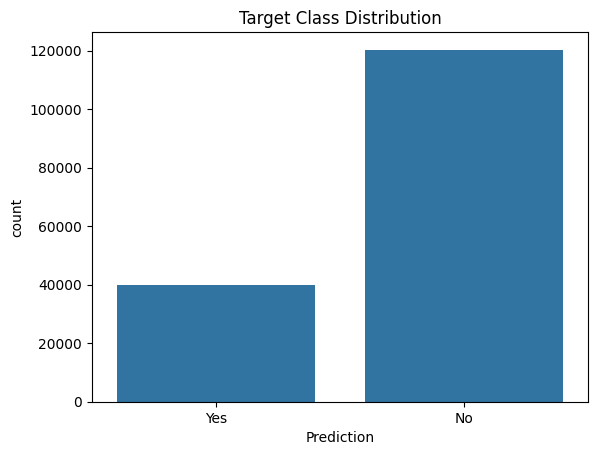

In [ ]:
# Split X and y
print(df[TARGET_COL].value_counts(dropna=False))

sns.countplot(x=TARGET_COL, data=df)
plt.title("Target Class Distribution")
plt.show()

In [6]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", label_encoder.classes_)
print(pd.Series(y_encoded).value_counts())

Target classes: ['No' 'Yes']
0    120270
1     40022
Name: count, dtype: int64


In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

X_train shape: (128233, 24)
X_test shape : (32059, 24)

Train class distribution:
0    96216
1    32017
Name: count, dtype: int64

Test class distribution:
0    24054
1     8005
Name: count, dtype: int64


In [ ]:
# Preprocessor Pipeline

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Population', 'Incidence_Rate', 'Mortality_Rate', 'Age', 'Survival_Rate', 'Cost_of_Treatment']

Categorical features:
['Country', 'Region', 'Gender', 'Alcohol_Consumption', 'Smoking_Status', 'Hepatitis_B_Status', 'Hepatitis_C_Status', 'Obesity', 'Diabetes', 'Rural_or_Urban', 'Seafood_Consumption', 'Herbal_Medicine_Use', 'Healthcare_Access', 'Screening_Availability', 'Treatment_Availability', 'Liver_Transplant_Access', 'Ethnicity', 'Preventive_Care']


In [ ]:
#  outlier capper

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        self.columns_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.factor * iqr
        self.upper_bounds_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X.columns = self.columns_
        for col in self.columns_:
            X[col] = X[col].clip(self.lower_bounds_[col], self.upper_bounds_[col])
        return X

In [10]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_capper', IQRCapper(factor=1.5)),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
    ],
    remainder='drop'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [ ]:
# 5-Fold CV

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [ ]:
# KNN Hyperparameter Tuning on Original Data

from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
knn_scores = []

for k in k_range:
    knn_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])

    score = cross_val_score(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    ).mean()

    knn_scores.append(score)

best_k = k_range[np.argmax(knn_scores)]
print("Best K:", best_k)
print("Best CV Score:", max(knn_scores))

Best K: 7
Best CV Score: 0.6515595746986517


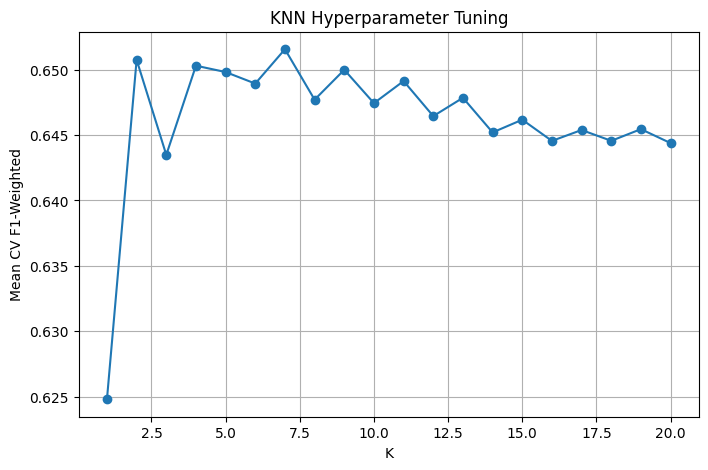

In [13]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range), knn_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Mean CV F1-Weighted")
plt.title("KNN Hyperparameter Tuning")
plt.grid(True)
plt.show()

In [ ]:
# Train KNN on Original Data

best_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])

best_knn.fit(X_train, y_train)

y_pred_knn = best_knn.predict(X_test)
y_score_knn = best_knn.predict_proba(X_test)[:, 1]

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)


print("KNN Accuracy :", knn_accuracy)
print("KNN Precision:", knn_precision)
print("KNN Recall   :", knn_recall)
print("KNN F1-score :", knn_f1)

KNN Accuracy : 0.717863938363642
KNN Precision: 0.630798260272996
KNN Recall   : 0.717863938363642
KNN F1-score : 0.6535405046080981


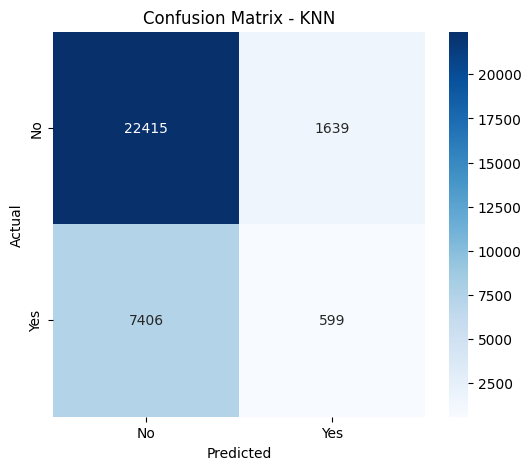

In [15]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Linear SVM on Original Data

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

svm_param_grid = {'classifier__C': [0.1, 1, 10]} 

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True
)

svm_grid.fit(X_train, y_train)

print("Best Linear SVM Params:", svm_grid.best_params_)
print("Best Linear SVM CV Score:", svm_grid.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Linear SVM Params: {'classifier__C': 0.1}
Best Linear SVM CV Score: 0.6432904651252301


In [ ]:

best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test)


if hasattr(best_svm.named_steps['classifier'], 'decision_function'):
    y_score_svm = best_svm.decision_function(X_test)
else:
    
    y_score_svm = best_svm.predict_proba(X_test)[:, 1]


svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_recall = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

# Comment: Linear SVM provides good linear separation; decision_function used for ROC
print("SVM Accuracy :", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall   :", svm_recall)
print("SVM F1-score :", svm_f1)

print("\nClassification Report :")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_, zero_division=0))

SVM Accuracy : 0.7503041267662747
SVM Precision: 0.562956282642502
SVM Recall   : 0.7503041267662747
SVM F1-score : 0.6432668175016831

Classification Report (اختياري للتسريع):
              precision    recall  f1-score   support

          No       0.75      1.00      0.86     24054
         Yes       0.00      0.00      0.00      8005

    accuracy                           0.75     32059
   macro avg       0.38      0.50      0.43     32059
weighted avg       0.56      0.75      0.64     32059



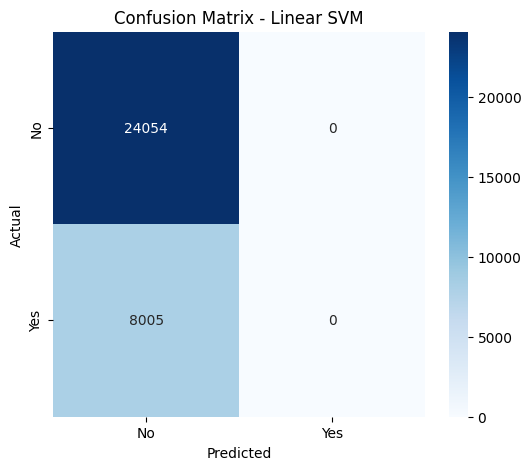

In [ ]:
# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)


plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm, 
    annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Decision Tree on Original Data

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 5, 10, 15, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
}

In [23]:
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best Decision Tree CV Score:", dt_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Decision Tree Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 30, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best Decision Tree CV Score: 0.6515346972222315


In [24]:
best_dt = dt_grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_score_dt = best_dt.predict_proba(X_test)[:, 1]

print("DT Accuracy :", accuracy_score(y_test, y_pred_dt))
print("DT Precision:", precision_score(y_test, y_pred_dt, average='weighted', zero_division=0))
print("DT Recall   :", recall_score(y_test, y_pred_dt, average='weighted', zero_division=0))
print("DT F1-score :", f1_score(y_test, y_pred_dt, average='weighted', zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_, zero_division=0))

DT Accuracy : 0.696060388658411
DT Precision: 0.624044243276312
DT Recall   : 0.696060388658411
DT F1-score : 0.6483443658597802

Classification Report:
              precision    recall  f1-score   support

          No       0.75      0.89      0.82     24054
         Yes       0.25      0.11      0.15      8005

    accuracy                           0.70     32059
   macro avg       0.50      0.50      0.48     32059
weighted avg       0.62      0.70      0.65     32059



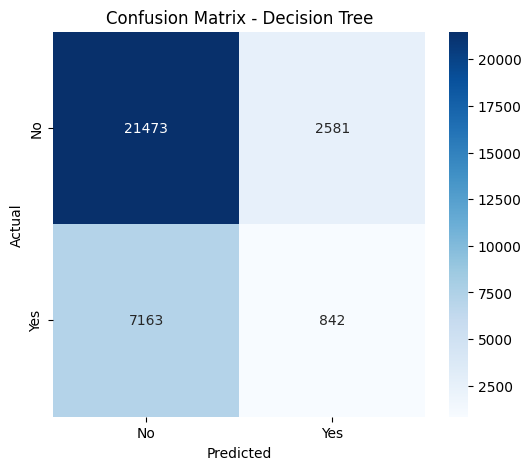

In [25]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Naive Bayes on Original Data

nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

nb_param_grid = {
    'classifier__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

In [27]:
nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True
)

nb_grid.fit(X_train, y_train)

print("Best Naive Bayes Params:", nb_grid.best_params_)
print("Best Naive Bayes CV Score:", nb_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Naive Bayes Params: {'classifier__var_smoothing': 1e-09}
Best Naive Bayes CV Score: 0.6502257408533655


In [ ]:
best_nb = nb_grid.best_estimator_

y_pred_nb = best_nb.predict(X_test)
y_score_nb = best_nb.predict_proba(X_test)[:, 1]

# Comment: Naive Bayes is simple and fast; works well for independent features.
print("NB Accuracy :", accuracy_score(y_test, y_pred_nb))
print("NB Precision:", precision_score(y_test, y_pred_nb, average='weighted', zero_division=0))
print("NB Recall   :", recall_score(y_test, y_pred_nb, average='weighted', zero_division=0))
print("NB F1-score :", f1_score(y_test, y_pred_nb, average='weighted', zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_, zero_division=0))

NB Accuracy : 0.7002401821641349
NB Precision: 0.6250149598763164
NB Recall   : 0.7002401821641349
NB F1-score : 0.6494955005449549

Classification Report:
              precision    recall  f1-score   support

          No       0.75      0.90      0.82     24054
         Yes       0.25      0.10      0.14      8005

    accuracy                           0.70     32059
   macro avg       0.50      0.50      0.48     32059
weighted avg       0.63      0.70      0.65     32059



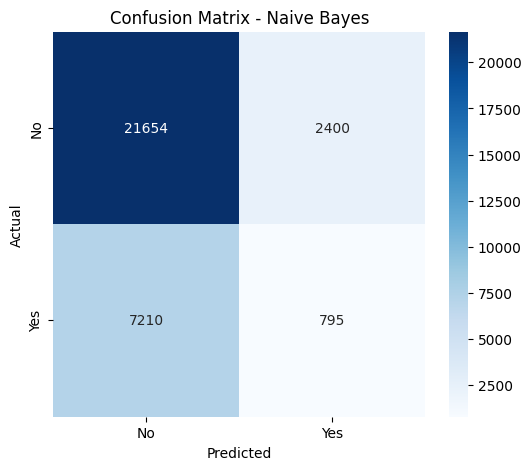

In [29]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
results_df = pd.DataFrame([
    {
        'Model': 'KNN',
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'Precision': precision_score(y_test, y_pred_knn, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred_knn, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)
    },
    {
        'Model': 'Linear SVM',
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred_dt, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)
    },
    {
        'Model': 'Naive Bayes',
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'Precision': precision_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)
    }
])

results_df.sort_values(by='F1-Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.717864,0.630798,0.717864,0.653541
3,Naive Bayes,0.700240,0.625015,0.700240,0.649496
2,Decision Tree,0.696060,0.624044,0.696060,0.648344
1,Linear SVM,0.750304,0.562956,0.750304,0.643267


In [31]:
best_model_name = results_df.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
print("Best model is:", best_model_name)

Best model is: KNN


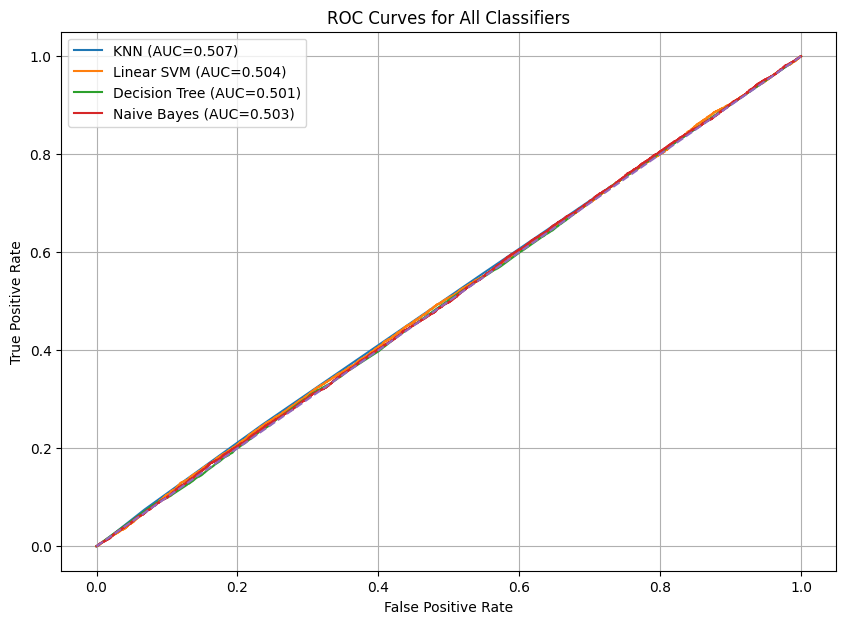

In [ ]:
# Cell 12: ROC Curves for All Models

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)  # y_score_svm = decision_function
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_score_nb)

# Comment: Compare AUC to see which model discriminates best between classes.

auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)
auc_dt = auc(fpr_dt, tpr_dt)
auc_nb = auc(fpr_nb, tpr_nb)


plt.figure(figsize=(10,7))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc_knn:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'Linear SVM (AUC={auc_svm:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={auc_nb:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Classifiers")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
def plot_learning_curve_errors(estimator, model_name, X_train, y_train, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 4),
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_error = 1 - np.mean(train_scores, axis=1)
    val_error = 1 - np.mean(val_scores, axis=1)

    return train_sizes, train_error, val_error

In [37]:
train_sizes_knn, train_error_knn, val_error_knn = plot_learning_curve_errors(best_knn, 'KNN', X_train, y_train, cv)
train_sizes_svm, train_error_svm, val_error_svm = plot_learning_curve_errors(best_svm, 'Linear SVM', X_train, y_train, cv)
train_sizes_dt, train_error_dt, val_error_dt = plot_learning_curve_errors(best_dt, 'Decision Tree', X_train, y_train, cv)
train_sizes_nb, train_error_nb, val_error_nb = plot_learning_curve_errors(best_nb, 'Naive Bayes', X_train, y_train, cv)

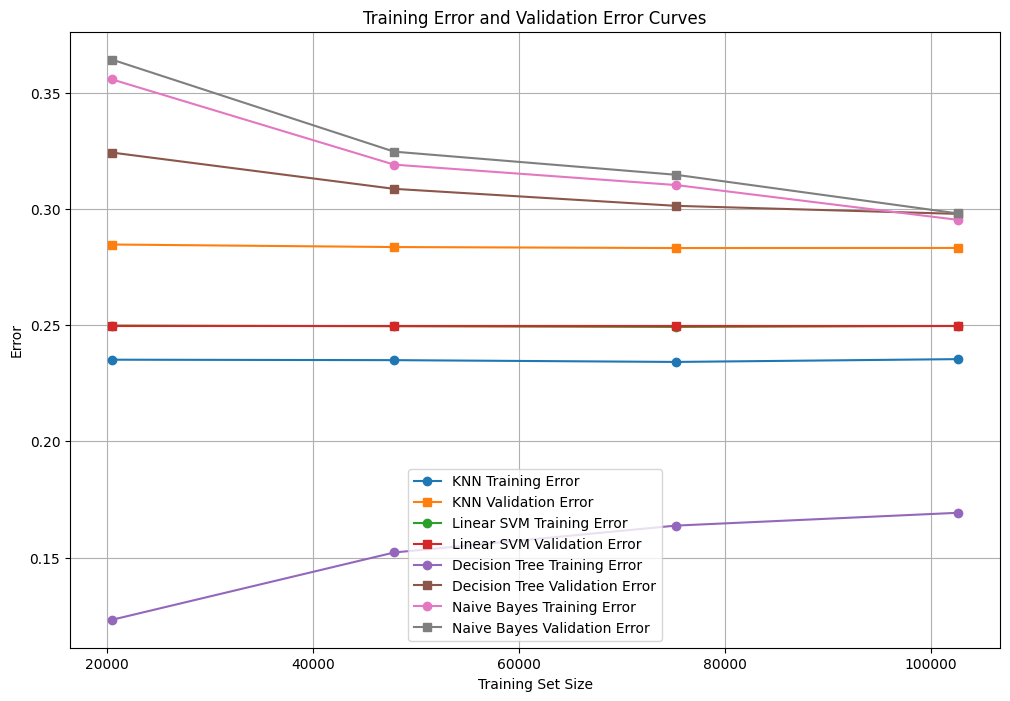

In [38]:
plt.figure(figsize=(12,8))

plt.plot(train_sizes_knn, train_error_knn, marker='o', label='KNN Training Error')
plt.plot(train_sizes_knn, val_error_knn, marker='s', label='KNN Validation Error')

plt.plot(train_sizes_svm, train_error_svm, marker='o', label='Linear SVM Training Error')
plt.plot(train_sizes_svm, val_error_svm, marker='s', label='Linear SVM Validation Error')

plt.plot(train_sizes_dt, train_error_dt, marker='o', label='Decision Tree Training Error')
plt.plot(train_sizes_dt, val_error_dt, marker='s', label='Decision Tree Validation Error')

plt.plot(train_sizes_nb, train_error_nb, marker='o', label='Naive Bayes Training Error')
plt.plot(train_sizes_nb, val_error_nb, marker='s', label='Naive Bayes Validation Error')

plt.xlabel("Training Set Size")
plt.ylabel("Error")
plt.title("Training Error and Validation Error Curves")
plt.legend()
plt.grid(True)
plt.show()

- KNN: Low training error, validation error close → good generalization.
- Linear SVM: Stable train & validation errors (~0.25) → low bias, low variance.
- Decision Tree: Very low training error (~0.12), higher validation error (~0.32) → overfitting.
- Naive Bayes: Train ~0.32, validation ~0.36 → high bias, low variance, stable.

## Part 2
### Noisy Data


In [ ]:

# Use same best parameters, train on noisy data

noisy_df = df.copy()

group_yes = noisy_df[noisy_df[TARGET_COL] == 'Yes'].copy()
group_no = noisy_df[noisy_df[TARGET_COL] == 'No'].copy()

yes_flip_n = int(round(0.05 * len(group_yes)))
no_flip_n = int(round(0.10 * len(group_no)))

rng = np.random.RandomState(RANDOM_STATE)

yes_indices = rng.choice(group_yes.index, size=yes_flip_n, replace=False)
no_indices = rng.choice(group_no.index, size=no_flip_n, replace=False)

noisy_df.loc[yes_indices, TARGET_COL] = 'No'
noisy_df.loc[no_indices, TARGET_COL] = 'Yes'

print("Original target distribution:")
print(df[TARGET_COL].value_counts())

print("\nNoisy target distribution:")
print(noisy_df[TARGET_COL].value_counts())

Original target distribution:
Prediction
No     120270
Yes     40022
Name: count, dtype: int64

Noisy target distribution:
Prediction
No     110244
Yes     50048
Name: count, dtype: int64


In [40]:
X_noisy = noisy_df.drop(columns=[TARGET_COL]).copy()
y_noisy = noisy_df[TARGET_COL].copy()

y_noisy_encoded = label_encoder.transform(y_noisy)

X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    X_noisy,
    y_noisy_encoded,
    test_size=TEST_SIZE,
    stratify=y_noisy_encoded,
    random_state=RANDOM_STATE
)

print("Noisy X_train shape:", X_train_noisy.shape)
print("Noisy X_test shape :", X_test_noisy.shape)

Noisy X_train shape: (128233, 24)
Noisy X_test shape : (32059, 24)


In [ ]:
from sklearn.base import clone


best_knn_noisy = clone(best_knn) 
best_knn_noisy.fit(X_train_noisy, y_train_noisy)


y_pred_knn_noisy = best_knn_noisy.predict(X_test_noisy)
y_score_knn_noisy = best_knn_noisy.predict_proba(X_test_noisy)[:, 1]


knn_noisy_accuracy = accuracy_score(y_test_noisy, y_pred_knn_noisy)
knn_noisy_precision = precision_score(y_test_noisy, y_pred_knn_noisy, average='weighted', zero_division=0)
knn_noisy_recall = recall_score(y_test_noisy, y_pred_knn_noisy, average='weighted', zero_division=0)
knn_noisy_f1 = f1_score(y_test_noisy, y_pred_knn_noisy, average='weighted', zero_division=0)

print("Noisy KNN Accuracy :", knn_noisy_accuracy)
print("Noisy KNN Precision:", knn_noisy_precision)
print("Noisy KNN Recall   :", knn_noisy_recall)
print("Noisy KNN F1-score :", knn_noisy_f1)

Noisy KNN Accuracy : 0.6316790916747247
Noisy KNN Precision: 0.5659983635169172
Noisy KNN Recall   : 0.6316790916747247
Noisy KNN F1-score : 0.5826546668080633


In [ ]:
from sklearn.base import clone


best_svm_noisy = clone(best_svm)
best_svm_noisy.fit(X_train_noisy, y_train_noisy)


y_pred_svm_noisy = best_svm_noisy.predict(X_test_noisy)


y_score_svm_noisy = best_svm_noisy.decision_function(X_test_noisy)


svm_noisy_accuracy = accuracy_score(y_test_noisy, y_pred_svm_noisy)
svm_noisy_precision = precision_score(y_test_noisy, y_pred_svm_noisy, average='weighted', zero_division=0)
svm_noisy_recall = recall_score(y_test_noisy, y_pred_svm_noisy, average='weighted', zero_division=0)
svm_noisy_f1 = f1_score(y_test_noisy, y_pred_svm_noisy, average='weighted', zero_division=0)

print("Noisy SVM Accuracy :", svm_noisy_accuracy)
print("Noisy SVM Precision:", svm_noisy_precision)
print("Noisy SVM Recall   :", svm_noisy_recall)
print("Noisy SVM F1-score :", svm_noisy_f1)

Noisy SVM Accuracy : 0.6877631866246607
Noisy SVM Precision: 0.47301820087610796
Noisy SVM Recall   : 0.6877631866246607
Noisy SVM F1-score : 0.5605267428804297


In [ ]:
from sklearn.base import clone


best_dt_noisy = clone(best_dt)
best_dt_noisy.fit(X_train_noisy, y_train_noisy)


y_pred_dt_noisy = best_dt_noisy.predict(X_test_noisy)
y_score_dt_noisy = best_dt_noisy.predict_proba(X_test_noisy)[:, 1]


dt_noisy_accuracy = accuracy_score(y_test_noisy, y_pred_dt_noisy)
dt_noisy_precision = precision_score(y_test_noisy, y_pred_dt_noisy, average='weighted', zero_division=0)
dt_noisy_recall = recall_score(y_test_noisy, y_pred_dt_noisy, average='weighted', zero_division=0)
dt_noisy_f1 = f1_score(y_test_noisy, y_pred_dt_noisy, average='weighted', zero_division=0)
print("Noisy DT Accuracy :", dt_noisy_accuracy)
print("Noisy DT Precision:", dt_noisy_precision)
print("Noisy DT Recall   :", dt_noisy_recall)
print("Noisy DT F1-score :", dt_noisy_f1)

Noisy DT Accuracy : 0.6285286503010075
Noisy DT Precision: 0.5691543698938675
Noisy DT Recall   : 0.6285286503010075
Noisy DT F1-score : 0.5851545932845822


In [53]:
best_nb_noisy = clone(best_nb)
best_nb_noisy.fit(X_train_noisy, y_train_noisy)


y_pred_nb_noisy = best_nb_noisy.predict(X_test_noisy)
y_score_nb_noisy = best_nb_noisy.predict_proba(X_test_noisy)[:, 1]
nb_noisy_accuracy = accuracy_score(y_test_noisy, y_pred_nb_noisy)
nb_noisy_precision = precision_score(y_test_noisy, y_pred_nb_noisy, average='weighted', zero_division=0)
nb_noisy_recall = recall_score(y_test_noisy, y_pred_nb_noisy, average='weighted', zero_division=0)
nb_noisy_f1 = f1_score(y_test_noisy, y_pred_nb_noisy, average='weighted', zero_division=0)  

print("Noisy NB Accuracy:", nb_noisy_accuracy)
print("Noisy NB Precision:", nb_noisy_precision)
print("Noisy NB Recall   :", nb_noisy_recall)
print("Noisy NB F1-score :", nb_noisy_f1)   

Noisy NB Accuracy: 0.6587229795065348
Noisy NB Precision: 0.5750139005467251
Noisy NB Recall   : 0.6587229795065348
Noisy NB F1-score : 0.5839086389935336


In [54]:
noisy_results_df = pd.DataFrame([
    {
        'Model': 'KNN',
        'Accuracy': accuracy_score(y_test_noisy, y_pred_knn_noisy),
        'Precision': precision_score(y_test_noisy, y_pred_knn_noisy, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_noisy, y_pred_knn_noisy, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test_noisy, y_pred_knn_noisy, average='weighted', zero_division=0)
    },
    {
        'Model': 'Linear SVM',
        'Accuracy': accuracy_score(y_test_noisy, y_pred_svm_noisy),
        'Precision': precision_score(y_test_noisy, y_pred_svm_noisy, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_noisy, y_pred_svm_noisy, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test_noisy, y_pred_svm_noisy, average='weighted', zero_division=0)
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test_noisy, y_pred_dt_noisy),
        'Precision': precision_score(y_test_noisy, y_pred_dt_noisy, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_noisy, y_pred_dt_noisy, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test_noisy, y_pred_dt_noisy, average='weighted', zero_division=0)
    },
    {
        'Model': 'Naive Bayes',
        'Accuracy': accuracy_score(y_test_noisy, y_pred_nb_noisy),
        'Precision': precision_score(y_test_noisy, y_pred_nb_noisy, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_noisy, y_pred_nb_noisy, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test_noisy, y_pred_nb_noisy, average='weighted', zero_division=0)
    }
])

noisy_results_df.sort_values(by='F1-Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
2,Decision Tree,0.628529,0.569154,0.628529,0.585155
3,Naive Bayes,0.658723,0.575014,0.658723,0.583909
0,KNN,0.631679,0.565998,0.631679,0.582655
1,Linear SVM,0.687763,0.473018,0.687763,0.560527


In [55]:
comparison_df = results_df.merge(noisy_results_df, on='Model', suffixes=('_Clean', '_Noisy'))

comparison_df['Accuracy_Drop'] = comparison_df['Accuracy_Clean'] - comparison_df['Accuracy_Noisy']
comparison_df['F1_Drop'] = comparison_df['F1-Score_Clean'] - comparison_df['F1-Score_Noisy']

comparison_df.sort_values(by='F1_Drop')

,Model,Accuracy_Clean,Precision_Clean,Recall_Clean,F1-Score_Clean,Accuracy_Noisy,Precision_Noisy,Recall_Noisy,F1-Score_Noisy,Accuracy_Drop,F1_Drop
2,Decision Tree,0.696060,0.624044,0.696060,0.648344,0.628529,0.569154,0.628529,0.585155,0.067532,0.063190
3,Naive Bayes,0.700240,0.625015,0.700240,0.649496,0.658723,0.575014,0.658723,0.583909,0.041517,0.065587
0,KNN,0.717864,0.630798,0.717864,0.653541,0.631679,0.565998,0.631679,0.582655,0.086185,0.070886
1,Linear SVM,0.750304,0.562956,0.750304,0.643267,0.687763,0.473018,0.687763,0.560527,0.062541,0.082740


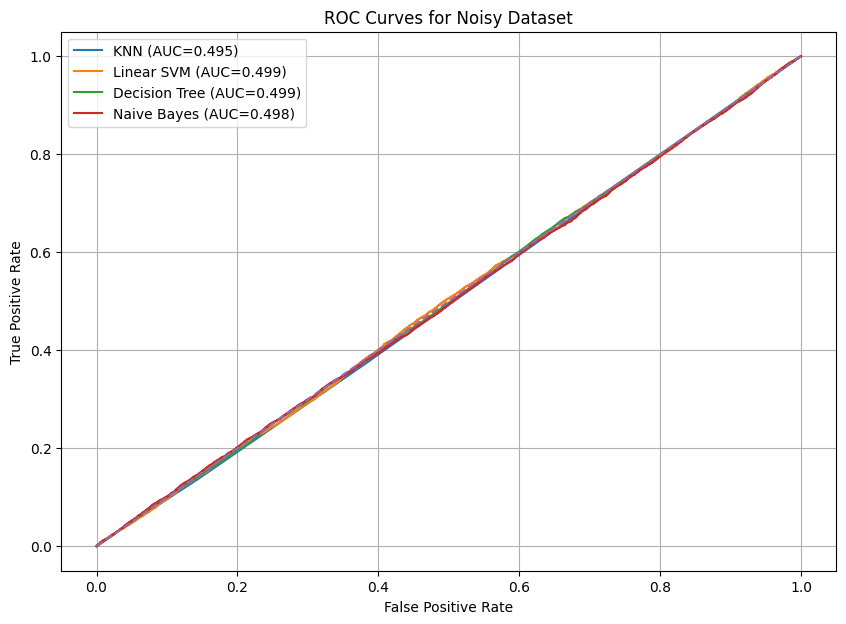

In [56]:
fpr_knn_n, tpr_knn_n, _ = roc_curve(y_test_noisy, y_score_knn_noisy)
fpr_svm_n, tpr_svm_n, _ = roc_curve(y_test_noisy, y_score_svm_noisy)
fpr_dt_n, tpr_dt_n, _ = roc_curve(y_test_noisy, y_score_dt_noisy)
fpr_nb_n, tpr_nb_n, _ = roc_curve(y_test_noisy, y_score_nb_noisy)

auc_knn_n = auc(fpr_knn_n, tpr_knn_n)
auc_svm_n = auc(fpr_svm_n, tpr_svm_n)
auc_dt_n = auc(fpr_dt_n, tpr_dt_n)
auc_nb_n = auc(fpr_nb_n, tpr_nb_n)

plt.figure(figsize=(10,7))
plt.plot(fpr_knn_n, tpr_knn_n, label=f'KNN (AUC={auc_knn_n:.3f})')
plt.plot(fpr_svm_n, tpr_svm_n, label=f'Linear SVM (AUC={auc_svm_n:.3f})')
plt.plot(fpr_dt_n, tpr_dt_n, label=f'Decision Tree (AUC={auc_dt_n:.3f})')
plt.plot(fpr_nb_n, tpr_nb_n, label=f'Naive Bayes (AUC={auc_nb_n:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Noisy Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
train_sizes_knn_n, train_error_knn_n, val_error_knn_n = plot_learning_curve_errors(best_knn_noisy, 'KNN', X_train_noisy, y_train_noisy, cv)
train_sizes_svm_n, train_error_svm_n, val_error_svm_n = plot_learning_curve_errors(best_svm_noisy, 'Linear SVM', X_train_noisy, y_train_noisy, cv)
train_sizes_dt_n, train_error_dt_n, val_error_dt_n = plot_learning_curve_errors(best_dt_noisy, 'Decision Tree', X_train_noisy, y_train_noisy, cv)
train_sizes_nb_n, train_error_nb_n, val_error_nb_n = plot_learning_curve_errors(best_nb_noisy, 'Naive Bayes', X_train_noisy, y_train_noisy, cv)

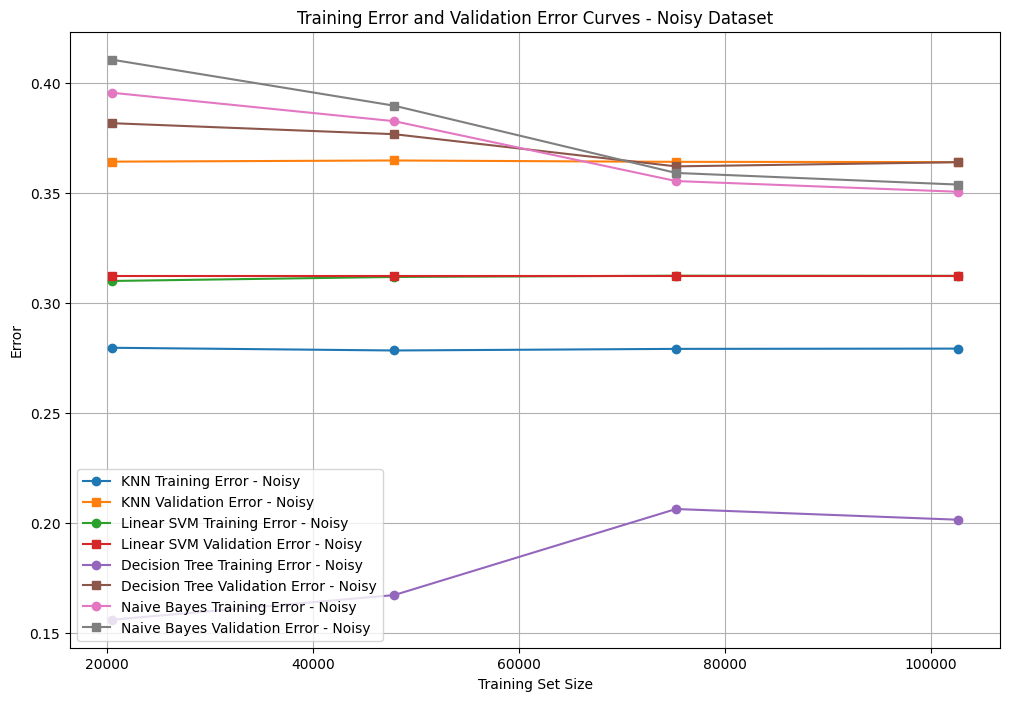

In [58]:
plt.figure(figsize=(12,8))

plt.plot(train_sizes_knn_n, train_error_knn_n, marker='o', label='KNN Training Error - Noisy')
plt.plot(train_sizes_knn_n, val_error_knn_n, marker='s', label='KNN Validation Error - Noisy')

plt.plot(train_sizes_svm_n, train_error_svm_n, marker='o', label='Linear SVM Training Error - Noisy')
plt.plot(train_sizes_svm_n, val_error_svm_n, marker='s', label='Linear SVM Validation Error - Noisy')

plt.plot(train_sizes_dt_n, train_error_dt_n, marker='o', label='Decision Tree Training Error - Noisy')
plt.plot(train_sizes_dt_n, val_error_dt_n, marker='s', label='Decision Tree Validation Error - Noisy')

plt.plot(train_sizes_nb_n, train_error_nb_n, marker='o', label='Naive Bayes Training Error - Noisy')
plt.plot(train_sizes_nb_n, val_error_nb_n, marker='s', label='Naive Bayes Validation Error - Noisy')

plt.xlabel("Training Set Size")
plt.ylabel("Error")
plt.title("Training Error and Validation Error Curves - Noisy Dataset")
plt.legend()
plt.grid(True)
plt.show()

"The learning curves indicate that KNN maintains the best balance between training and validation errors on noisy data. Decision Tree shows significant overfitting with very low training error but high validation error. Naive Bayes remains stable but biased, while Linear SVM shows moderate bias with consistent performance across different training sizes."

# summary

- Linear SVM: Best accuracy on clean data, but sensitive to label noise; F1 drops significantly under noisy conditions.
- KNN: Balanced performance; slightly lower accuracy than Linear SVM on clean data, but more robust to noise with smaller F1 drop.
- Decision Tree: Moderate accuracy and F1; prone to overfitting on clean data, moderately affected by noise.
- Naive Bayes: Simple and stable; slightly lower accuracy, minor F1 drop under noisy data.
# Overall Insight:
 For clean datasets, Linear SVM is preferred; for noisy datasets, KNN or Naive Bayes are more robust.